### K-means Clustering
What is Clustering?
Clustering is an unsupervised machine learning technique used to group similar observations together.

The goal is to:

Identify groups within a dataset.
Place observations that are similar to each other in the same group.
Separate observations that are different from each other.
Because clustering is unsupervised, the dataset does not need a target variable or predefined class labels.

What is K-means clustering?
K-means is an unsupervised machine learning algorithm used to group similar data points into clusters.

The k-means algorithm searches for a pre-determined number of clusters within an unlabeled multidimensional dataset.

It accomplishes this using a simple conception of what the optimal clustering looks like:

The "cluster center" is the arithmetic mean of all the points belonging to the cluster.
Each point is closer to its own cluster center than to other cluster centers.
K-Means tries to create clusters such that:

Observations within the same cluster are as similar as possible, while observations in different clusters are as different as possible.

How the K-means algorithm works:
Initialization: The algorithm begins by randomly selecting 'K' data points from the dataset to serve as initial cluster centroids.

Assignment: Each data point in the dataset is assigned to the nearest centroid based on a chosen distance metric (commonly Euclidean distance). This forms 'K' initial clusters.

### Importing the necessary libraries 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

### Creating a custom dataset
#### We will generate a synthetic dataset with make_blobs

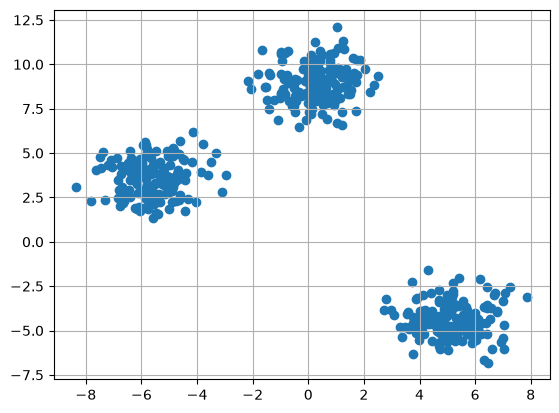

In [2]:
X,y = make_blobs(n_samples = 500,n_features = 2,centers = 3,random_state = 23)

fig = plt.figure(0)
plt.grid(True)
plt.scatter(X[:,0],X[:,1])
plt.show()

#### Initializing random centroids 
We will randomly initialize the centroids for K-Means clustering

np.random.seed(23): Ensures reproducibility by fixing the random seed.
The for loop initializes k random centroids, with values between -2 and 2, for a 2D dataset.

In [3]:
k = 3

clusters = {}
np.random.seed(23)

for idx in range(k):
    center = 2*(2*np.random.random((X.shape[1],))-1)
    points = []
    cluster = {
        'center' : center,
        'points' : []
    }
    
    clusters[idx] = cluster
    
clusters

{0: {'center': array([0.06919154, 1.78785042]), 'points': []},
 1: {'center': array([ 1.06183904, -0.87041662]), 'points': []},
 2: {'center': array([-1.11581855,  0.74488834]), 'points': []}}

#### Plotting random initialized centre with data points 
We will now plot the data points and the initial centroids.

plt.grid(): Plots a grid.
plt.scatter(center[0], center[1], marker='*', c='red'): Plots the cluster center as a red star (* marker).

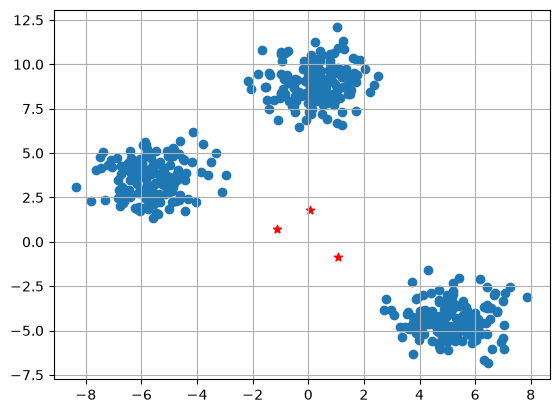

In [4]:
plt.scatter(X[:,0],X[:,1])
plt.grid(True)
for i in clusters:
    center = clusters[i]['center']
    plt.scatter(center[0],center[1],marker = '*',c = 'red')
plt.show()

#### Defining Eucalidian distance

To assign data points to the nearest centroid, we define a distance function:

np.sqrt(): Computes the square root of a number or array element-wise.
np.sum(): Sums all elements in an array or along a specified axis

In [5]:
def distance(p1,p2):
    return np.sqrt(np.sum((p1-p2)**2))

#### Creating Assign and update functions
Next, we define functions to assign points to the nearest centroid and update the centroids based on the average of the points assigned to each cluster.

dist.append(dis): Appends the calculated distance to the list dist.

curr_cluster = np.argmin(dist): Finds the index of the closest cluster by selecting the minimum distance.

new_center = points.mean(axis=0): Calculates the new centroid by taking the mean of the points in the cluster.

In [6]:
def assign_clusters(X, clusters):
    for idx in range(X.shape[0]):
        dist = []
        
        curr_x = X[idx]
        
        for i in range(k):
            dis = distance(curr_x,clusters[i]['center'])
            dist.append(dis)
        curr_cluster = np.argmin(dist)
        clusters[curr_cluster]['points'].append(curr_x)
    return clusters

def update_clusters(X, clusters):
    for i in range(k):
        points = np.array(clusters[i]['points'])
        if points.shape[0] > 0:
            new_center = points.mean(axis =0)
            clusters[i]['center'] = new_center
            
            clusters[i]['points'] = []
    return clusters

#### Predicting the cluster for the data points
We create a function to predict the cluster for each data point based on the final centroids.

pred.append(np.argmin(dist)): Appends the index of the closest cluster (the one with the minimum distance) to pred.

In [7]:
def pred_cluster(X, clusters):
    pred = []
    for i in range(X.shape[0]):
        dist = []
        for j in range(k):
            dist.append(distance(X[i],clusters[j]['center']))
        pred.append(np.argmin(dist))
    return pred

### Assigning, Updating and Predicting the Cluster Centers
We assign points to clusters, update the centroids and predict the final cluster labels.

assign_clusters(X, clusters): Assigns data points to the nearest centroids.

update_clusters(X, clusters): Recalculates the centroids.

pred_cluster(X, clusters): Predicts the final clusters for all data points.

In [8]:
clusters = assign_clusters(X,clusters)
clusters = update_clusters(X,clusters)
pred = pred_cluster(X,clusters)

#### Plotting Data Points with Predicted Cluster Centers
Finally, we plot the data points, colored by their predicted clusters, along with the updated centroids.

center = clusters[i]['center']: Retrieves the center (centroid) of the current cluster.

plt.scatter(center[0], center[1], marker='^', c='red'): Plots the cluster center as a red triangle (^ marker).

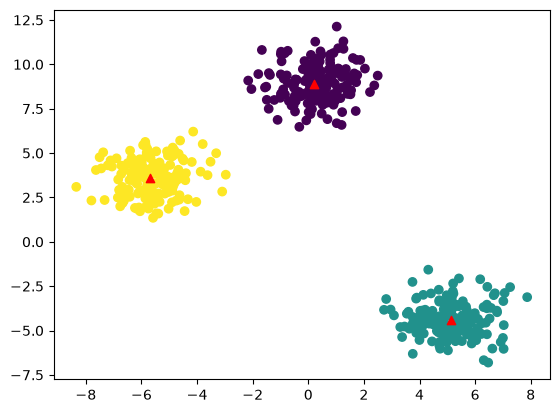

In [9]:
plt.scatter(X[:,0],X[:,1],c = pred)
for i in clusters:
    center = clusters[i]['center']
    plt.scatter(center[0],center[1],marker = '^',c = 'red')
plt.show()

Challenges with K-Means Clustering
K-Means algorithm has the following limitations:

Choosing the Right Number of Clusters (k): One of the biggest challenges is deciding how many clusters to use.

Sensitive to Initial Centroids: The final clusters can vary depending on the initial random placement of centroids.

Non-Spherical Clusters: K-Means assumes that the clusters are spherical and equally sized. This can be a problem when the actual clusters in the data are of different shapes or densities.

Outliers: K-Means is sensitive to outliers, which can distort the centroid and, ultimately, the clusters.